# 03 · Forward in time on CIC-IDS2017

**Question.** Can a model trained on earlier capture days catch the next day's attacks, all of
which are attack types it has never seen?

Three folds, five seeds each. Thresholds are frozen on the validation day's benign flows at a 1%
budget before the test day is scored. A recall counts only if the actual test false positive rate
stayed within 1.5 times the budget; otherwise it is marked "over budget".

In [1]:
import sys, json, warnings
sys.path.insert(0, "..")  # make src/ importable from notebooks/
warnings.filterwarnings("ignore", message="X does not have valid feature names")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.reporting.plots import load_summary, recall_dots, recall_table, style, COLORS, NAMES, INK, MUTED
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 60)
REPORTS = "../reports"
summary = load_summary()

def finding(folds, labels=None, caveats=None):
    for f in folds:
        d = summary["folds"][f]
        quotable = {n: v["budgets"]["0.01"]["recall"]["median"]
                    for n, v in d["detectors"].items() if not v["budget_violated"]["0.01"]}
        broke = [NAMES[n] for n, v in d["detectors"].items() if v["budget_violated"]["0.01"]]
        # ties go to the single model (a hybrid that gave one model the whole budget is that model)
        best = max(quotable, key=lambda n: (quotable[n], "+" not in n)) if quotable else None
        line = f"{(labels or {}).get(f, f)}: "
        if d["unseen_test_families"]:
            line += f"unseen families {', '.join(d['unseen_test_families'])}. "
        line += (f"Best detector within its false-alarm budget: {NAMES[best]}, recall {quotable[best]:.1%} "
                 f"(median of {len(d['seeds'])} seeds)" if best else "No detector stayed within its false-alarm budget")
        if broke:
            line += f". Over budget (recall not quotable): {', '.join(broke)}"
        if best and d["detectors"][best].get("shortcut_flag"):
            line += f". Shortcut flag: one feature ({', '.join(d['best_single_feature'])}) comes within 0.05 AP of it"
        if (caveats or {}).get(f):
            line += f". CAVEAT: {caveats[f]}"
        print(line + ".")

finding(["2017_A", "2017_B", "2017_C"], {"2017_A": "Fold A (train Mon, test Wed)",
        "2017_B": "Fold B (train Mon-Tue, test Thu)", "2017_C": "Fold C (train Mon-Wed, test Fri)"},
        {"2017_B": "this recall rides on one victim-server TCP window value, not on attack behaviour "
                   "(see 'Explaining fold B')"})


Fold A (train Mon, test Wed): unseen families DoS, Heartbleed. No detector stayed within its false-alarm budget. Over budget (recall not quotable): Isolation Forest, Autoencoder.
Fold B (train Mon-Tue, test Thu): unseen families Infiltration, Web attack. Best detector within its false-alarm budget: LightGBM, recall 82.0% (median of 5 seeds). Over budget (recall not quotable): Logistic regression. CAVEAT: this recall rides on one victim-server TCP window value, not on attack behaviour (see 'Explaining fold B').
Fold C (train Mon-Wed, test Fri): unseen families Bot, DDoS, PortScan. Best detector within its false-alarm budget: LightGBM, recall 41.9% (median of 5 seeds). Over budget (recall not quotable): Isolation Forest, Autoencoder, Hybrid: LightGBM + anomaly model, Hybrid: log. regression + anomaly model. Shortcut flag: one feature (Fwd Packet Length Max) comes within 0.05 AP of it.


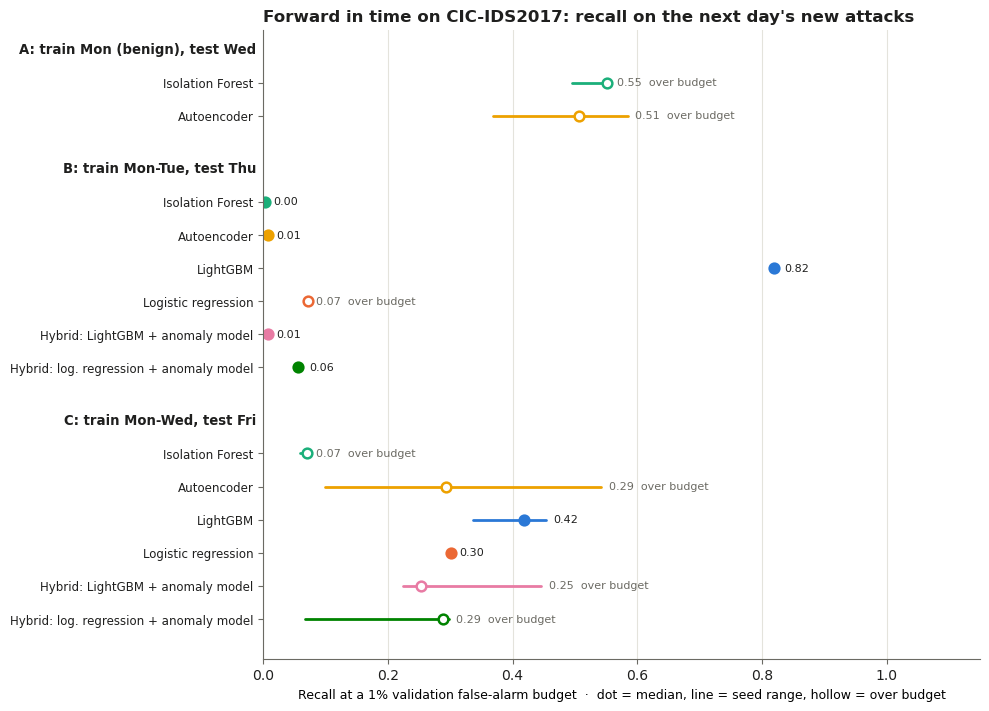

,fold,question,detector,recall (median),recall range,actual FPR range,AP (median),ROC AUC (median),prevalence
0,2017_A,unseen family,Isolation Forest,0.551,0.495-0.556,0.0188-0.0190,0.754,0.831,0.3641
1,2017_A,unseen family,Autoencoder,0.506,0.369-0.585,0.0085-0.0177,0.887,0.933,0.3641
2,2017_B,unseen family,Isolation Forest,0.003,0.003-0.004,0.0017-0.0019,0.008,0.695,0.0048
3,2017_B,unseen family,Autoencoder,0.008,0.002-0.009,0.0037-0.0065,0.006,0.599,0.0048
4,2017_B,unseen family,LightGBM,0.820,0.816-0.824,0.0084-0.0126,0.663,0.923,0.0048
5,2017_B,unseen family,Logistic regression,0.072,0.072-0.072,0.0116-0.0165,0.018,0.844,0.0048
6,2017_B,unseen family,Hybrid: LightGBM + anomaly model,0.008,0.002-0.009,0.0037-0.0065,NaN,NaN,0.0048
7,2017_B,unseen family,Hybrid: log. regression + anomaly model,0.055,0.054-0.062,0.0080-0.0107,NaN,NaN,0.0048
8,2017_C,unseen family,Isolation Forest,0.071,0.059-0.073,0.0334-0.0337,0.497,0.661,0.4110
9,2017_C,unseen family,Autoencoder,0.293,0.098-0.542,0.0687-0.0721,0.745,0.917,0.4110


In [2]:
FOLDS = ['2017_A', '2017_B', '2017_C']
LABELS = {'2017_A': 'A: train Mon (benign), test Wed', '2017_B': 'B: train Mon-Tue, test Thu', '2017_C': 'C: train Mon-Wed, test Fri'}
fig = recall_dots(summary, FOLDS, "Forward in time on CIC-IDS2017: recall on the next day's new attacks", LABELS)
plt.show()
recall_table(summary, FOLDS)

In [3]:
# Recall per attack family at the 1% budget (median over seeds, n = flows in the test set)
rows = {}
for f in FOLDS:
    fold = summary["folds"][f]
    for det, d in fold["detectors"].items():
        for fam, r in d["per_family_recall_at_1pct"].items():
            rows.setdefault((LABELS[f], fam), {})[NAMES[det]] = round(r["median"], 3)
pd.DataFrame(rows).T

Isolation Forest  Autoencoder  LightGBM  Logistic regression  Hybrid: LightGBM + anomaly model  Hybrid: log. regression + anomaly model
A: train Mon (benign), test Wed DoS                      0.551        0.506       NaN                  NaN                               NaN                                      NaN
                                Heartbleed               1.000        0.909       NaN                  NaN                               NaN                                      NaN
B: train Mon-Tue, test Thu      Infiltration             0.194        0.472     0.000                0.056                             0.472                                    0.444
                                Web attack               0.000        0.000     0.833                0.072                             0.000                                    0.049
C: train Mon-Wed, test Fri      Bot                      0.009        0.000     0.000                0.000                             0.000                                    0.008
                                DDoS                     0.159        0.202     0.920                0.636                             0.548                                    0.632
                                PortScan                 0.000        0.372     0.020                0.036                             0.017                                    0.016

## Explaining fold B before using it

Fold B is the one strong unseen-attack result: LightGBM, trained on Tuesday's FTP and SSH brute
force, catches most of Thursday's web attacks. The design required explaining it before using it.
`scripts/explain_forward_thursday.py` retrains the model without each of its top features.

In [4]:
ex = json.load(open(f"{REPORTS}/results/explain_2017_B.json"))
print("Recall per label (LightGBM, seed 42):", {k: round(v, 3) for k, v in ex["per_label_recall"].items()})
print("Window artifact:", ex["window_artifact"])
pd.DataFrame({k: v["per_label_recall"] for k, v in ex["ablations"].items()}).T.round(3)

Recall per label (LightGBM, seed 42): {'Infiltration': 0.167, 'Web Attack - Brute Force': 0.807, 'Web Attack - Sql Injection': 0.0, 'Web Attack - XSS': 0.925}
Window artifact: {'most_common_web_attack_value': 28960, 'web_attack_share_with_value': 0.8339449541284404, 'benign_share_with_value': 0.0030085814800301165, 'benign_ports_with_value': {'80': 6310, '443': 219, '139': 96, '21': 24, '43678': 1}}


,Infiltration,Web Attack - Brute Force,Web Attack - Sql Injection,Web Attack - XSS
without Init_Win_bytes_backward,0.00,0.054,0.0,0.071
without Fwd IAT Min,0.00,0.805,0.0,0.928
without Flow IAT Min,0.25,0.800,0.0,0.903
without Bwd Packets/s,0.25,0.807,0.0,0.920
without Total Fwd Packets,0.00,0.807,0.0,0.920
without all top 5,0.00,0.176,0.0,0.327


## What this shows

- **Fold B is an artifact, not transfer.** The recall rides on one feature,
  `Init_Win_bytes_backward`. Most Thursday web-attack flows carry the same backward TCP window
  value, the one printed above, which is likely the victim web server's default window; very few
  benign flows have it. Without that feature, recall falls to a few percent. The model learned
  "this server answered", not "this is an attack".
- **Fold C's DDoS detection is plausible transfer, with a caveat.** Trained on Wednesday's DoS,
  LightGBM flags most of Friday's DDoS, a closely related attack. One feature alone
  (`Fwd Packet Length Max`) comes close to the model, so the shortcut flag is raised. PortScan and
  Bot, which look nothing like Tuesday's or Wednesday's attacks, are almost never caught.
- **The anomaly models break their budgets.** Isolation Forest and the autoencoder are fitted to
  earlier days' benign traffic. On a new day, normal traffic shifts, and their "1%" thresholds let
  through 2-7% of benign flows. Their recall is therefore marked over budget.
- **Seeds matter for anomaly models.** The autoencoder's fold C recall ranges widely across
  seeds (see the table); LightGBM and logistic regression are stable.

## Limits

Five seeds measure fitting variation, not uncertainty about future traffic. Every day here has
been looked at before, so these are development results, not a fresh test.